# PyPEEC demo — simulating a planar inductor

[PyPEEC](https://pypeec.otvam.ch) is a 3D **quasi-magnetostatic PEEC** (Partial Element
Equivalent Circuit) field solver aimed at power-electronics magnetics. Geometry → 3D voxels
→ solve → terminal impedance + current/flux fields.

This notebook runs the bundled **planar spiral inductor** example end to end:
1. mesh the geometry into voxels,
2. solve and extract **L and R** from the terminal V/I,
3. sweep frequency to see the **AC-loss story** (skin/proximity), and
4. render the **current-density** and **loss** fields.

Why this matters for our LLC planar transformer: PEEC gives you the *frequency-dependent*
AC resistance and the current distribution across stacked copper — exactly the proximity-loss
effect we can't get from a hand calculation.


In [1]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt

import scilogger
scilogger.disable()                     # silence the (very verbose) solver logs
import scisave
import pypeec
print("pypeec", pypeec.__version__)

# self-bootstrap the bundled examples if missing
if not os.path.isdir("examples"):
    pypeec.run_extract_examples("examples")

EX      = "examples/examples_png/inductor_spiral"   # a planar spiral inductor (PNG-defined)
CFG_TOL = "examples/config/tolerance.yaml"
CFG_PLT = "examples/config/plotter.yaml"


pypeec 5.8.0


In [2]:
# --- mesh once (in memory), then solve and pull L, R from terminal V/I ---
geom = scisave.load_config(f"{EX}/geometry.yaml")
prob = scisave.load_config(f"{EX}/problem.yaml")
tol  = scisave.load_config(CFG_TOL)

voxel = pypeec.run_mesher_data(geom)    # geometry -> 3D voxel structure

def solve_LR(freq):
    """Solve at one frequency; return (R [Ohm], L [H])."""
    param = {**prob["sweep_solver"]["sim_default"]["param"], "freq": freq}
    p = {**prob, "sweep_solver": {"s": {"init": None, "param": param}}}
    sol = pypeec.run_solver_data(voxel, p, tol)
    sv = sol["data_sweep"]["s"]["source_values"]
    Z = (sv["src"]["V"] - sv["sink"]["V"]) / sv["src"]["I"]   # terminal impedance
    return Z.real, Z.imag / (2 * np.pi * freq)

f0 = 1e6
R, L = solve_LR(f0)
print(f"Planar spiral @ {f0/1e6:.0f} MHz:  L = {L*1e9:.2f} nH   "
      f"R = {R*1e3:.2f} mOhm   Q = {2*np.pi*f0*L/R:.1f}")


Planar spiral @ 1 MHz:  L = 17.92 nH   R = 30.91 mOhm   Q = 3.6


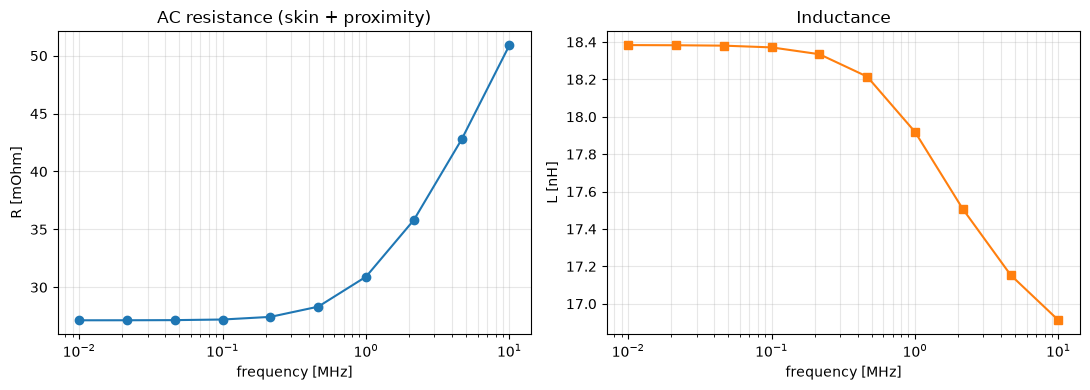

R rises 27.1 -> 50.9 mOhm across the sweep (1.9x) as current crowds to the surface/edges.


In [3]:
# --- frequency sweep: AC resistance and inductance ---
freqs = np.logspace(4, 7, 10)           # 10 kHz .. 10 MHz
RL = np.array([solve_LR(f) for f in freqs])
Rf, Lf = RL[:, 0], RL[:, 1]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.semilogx(freqs/1e6, Rf*1e3, "o-")
a1.set_xlabel("frequency [MHz]"); a1.set_ylabel("R [mOhm]")
a1.set_title("AC resistance (skin + proximity)"); a1.grid(True, which="both", alpha=0.3)

a2.semilogx(freqs/1e6, Lf*1e9, "s-", color="C1")
a2.set_xlabel("frequency [MHz]"); a2.set_ylabel("L [nH]")
a2.set_title("Inductance"); a2.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

print(f"R rises {Rf[0]*1e3:.1f} -> {Rf[-1]*1e3:.1f} mOhm across the sweep "
      f"({Rf[-1]/Rf[0]:.1f}x) as current crowds to the surface/edges.")


## Field visualization

The solver also gives the full 3D **current density** and **loss density**. We render them
headlessly (`plot_mode="png"`) via the file-based pipeline (the plotter wants the on-disk
`{meta, data}` solution format) and show them inline.


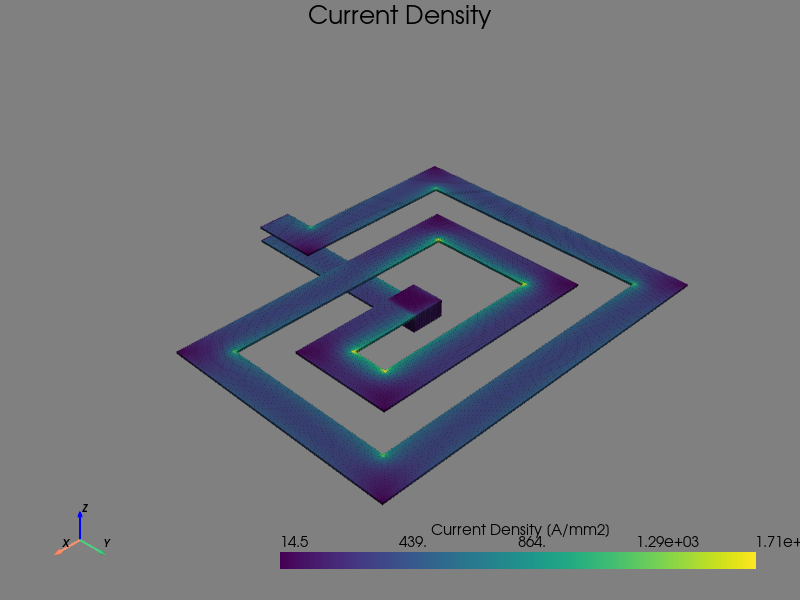

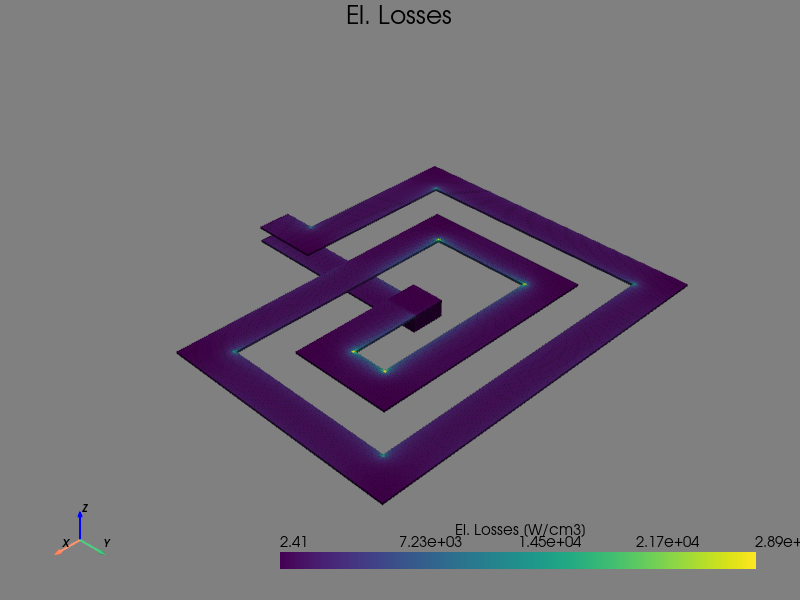

In [4]:
from IPython.display import Image, display

os.makedirs("out", exist_ok=True)
# file-based mesh+solve at 1 MHz -> proper solution file the plotter accepts
pypeec.run_mesher_file(file_geometry=f"{EX}/geometry.yaml", file_voxel="out/voxel.json.gz")
pypeec.run_solver_file(file_voxel="out/voxel.json.gz", file_problem=f"{EX}/problem.yaml",
                       file_tolerance=CFG_TOL, file_solution="out/solution.json.gz")
pypeec.run_plotter_file("out/solution.json.gz", CFG_PLT,
                        plot_mode="png", path="out",
                        tag_plot=["J_c_norm", "P_c_norm"])   # current density + losses

for tag in ["J_c_norm", "P_c_norm"]:
    hits = glob.glob(f"out/*{tag}.png")
    if hits:
        display(Image(hits[0]))


## Next steps — adapting this to our planar transformer

- **Geometry:** swap the bundled PNG spiral for our stackup. PyPEEC ingests PNG layers,
  GERBER (actual PCB copper!), STL, or programmatic 2D shapes stacked into layers — so we can
  model the real primary/secondary interleaving.
- **What we get:** per-winding AC resistance vs frequency (the proximity-loss number we can't
  hand-calc), leakage inductance from the field, and current-sharing between paralleled
  secondary layers.
- **Add the core:** the `examples_*/…core` cases show a magnetic (permeable) domain — needed to
  capture the ferrite and the gap for a real transformer model.
- **Caveat:** PEEC here is linear-material; ferrite saturation/loss isn't modeled — pair it with
  the Steinmetz core-loss calc for the full picture.
